[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/pravallikachepuri/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package movie_reviews to
[nltk_data]     /Users/pravallikachepuri/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/pravallikachepuri/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/pravallikachepuri/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/pravallikachepuri/nltk_data...


✅ All NLTK datasets downloaded!
✅ Paths set up!
✅ BASE_DIR   : /Users/pravallikachepuri/sentiment-analysis-nlp
✅ DATA_DIR   : /Users/pravallikachepuri/sentiment-analysis-nlp/data
✅ RESULTS_DIR: /Users/pravallikachepuri/sentiment-analysis-nlp/results
✅ MODELS_DIR : /Users/pravallikachepuri/sentiment-analysis-nlp/models

📌 Dataset shape   : (2000, 4)
📌 Positive reviews: 1000
📌 Negative reviews: 1000

📌 Sample text:
plot : two teen couples go to a church party , drink and then drive . they get into an accident . one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . what


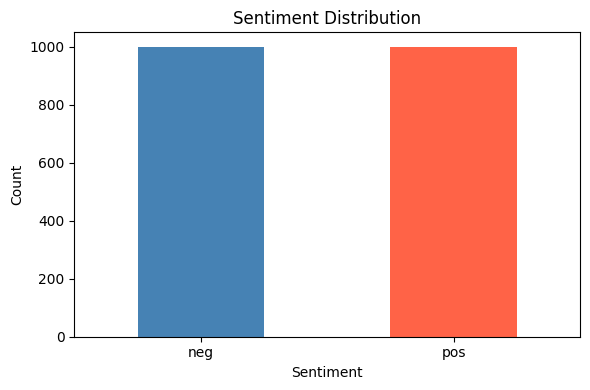


📌 Sentiment %:
sentiment
neg    50.0
pos    50.0
Name: proportion, dtype: float64
✅ Sentiment distribution saved!


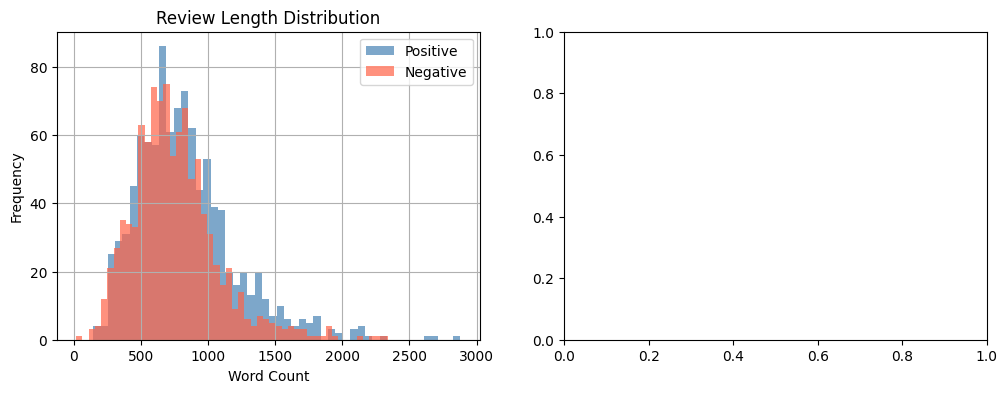

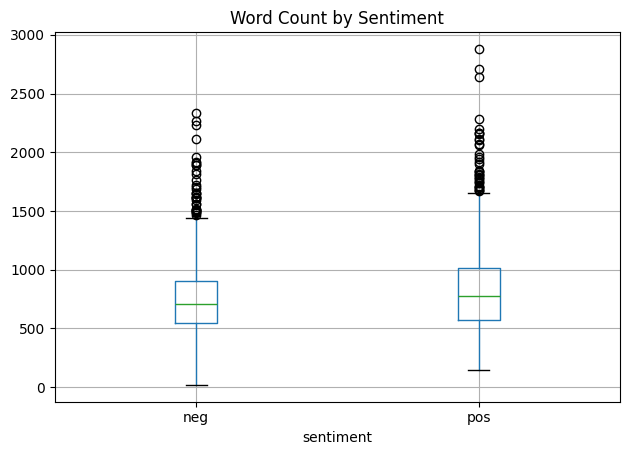

✅ Review length chart saved!


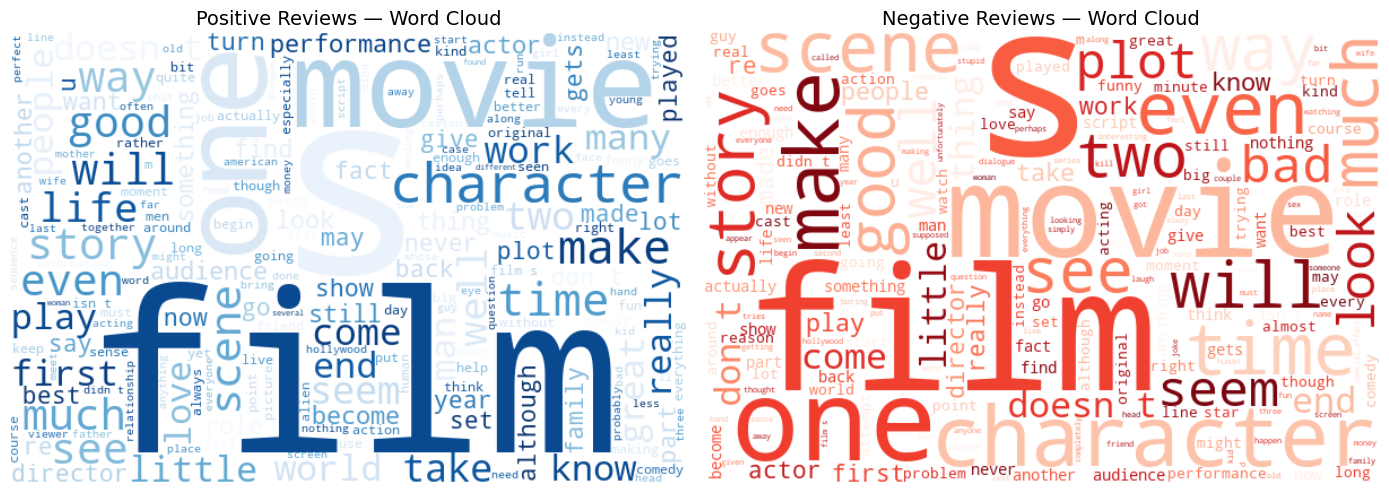

✅ WordClouds saved!

⏳ Cleaning text (this takes ~1 min)...
✅ Text cleaning done!

📌 Sample cleaned text:
plot two teen couple church party drink drive get accident one guy dy girlfriend continues see life nightmare deal watch movie sorta find critique mind fuck movie teen generation touch cool idea prese

📌 Saved to: /Users/pravallikachepuri/sentiment-analysis-nlp/data

🎉 Notebook 1 Complete!


In [2]:
# ============================================================
# 📊 NOTEBOOK 1 — EDA & Text Preprocessing
# ============================================================

# ── CELL 1: Download NLTK Data ───────────────────────────────
import nltk
nltk.download('punkt_tab')
nltk.download('movie_reviews')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
print("✅ All NLTK datasets downloaded!")

# ── CELL 2: Imports & Setup ──────────────────────────────────
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.corpus import movie_reviews, stopwords
from nltk.stem import WordNetLemmatizer
import re
import warnings
warnings.filterwarnings('ignore')

# ── Setup Paths ──────────────────────────────────────────────
BASE_DIR    = os.path.expanduser('~/sentiment-analysis-nlp')
DATA_DIR    = os.path.join(BASE_DIR, 'data')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
MODELS_DIR  = os.path.join(BASE_DIR, 'models')

os.makedirs(DATA_DIR,    exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

print("✅ Paths set up!")
print("✅ BASE_DIR   :", BASE_DIR)
print("✅ DATA_DIR   :", DATA_DIR)
print("✅ RESULTS_DIR:", RESULTS_DIR)
print("✅ MODELS_DIR :", MODELS_DIR)

# ── CELL 3: Load Dataset ─────────────────────────────────────
documents = [(list(movie_reviews.words(fileid)), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]

df = pd.DataFrame(documents, columns=['words', 'sentiment'])
df['text']  = df['words'].apply(lambda x: ' '.join(x))
df['label'] = df['sentiment'].map({'pos': 1, 'neg': 0})

print(f"\n📌 Dataset shape   : {df.shape}")
print(f"📌 Positive reviews: {(df['label']==1).sum()}")
print(f"📌 Negative reviews: {(df['label']==0).sum()}")
print(f"\n📌 Sample text:\n{df['text'].iloc[0][:200]}")

# ── CELL 4: Sentiment Distribution ───────────────────────────
plt.figure(figsize=(6, 4))
df['sentiment'].value_counts().plot(
    kind='bar', color=['steelblue', 'tomato'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sentiment_distribution.png'))
plt.show()

churn_rate = df['sentiment'].value_counts(normalize=True) * 100
print(f"\n📌 Sentiment %:\n{churn_rate}")
print("✅ Sentiment distribution saved!")

# ── CELL 5: Review Length Analysis ───────────────────────────
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df[df['label']==1]['word_count'].hist(
    bins=50, color='steelblue', alpha=0.7, label='Positive')
df[df['label']==0]['word_count'].hist(
    bins=50, color='tomato', alpha=0.7, label='Negative')
plt.title('Review Length Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 2, 2)
df.boxplot(column='word_count', by='sentiment')
plt.title('Word Count by Sentiment')
plt.suptitle('')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'review_length.png'))
plt.show()
print("✅ Review length chart saved!")

# ── CELL 6: WordClouds ───────────────────────────────────────
pos_text = ' '.join(df[df['label']==1]['text'].values)
neg_text = ' '.join(df[df['label']==0]['text'].values)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wordcloud_pos = WordCloud(
    width=600, height=400,
    background_color='white',
    colormap='Blues').generate(pos_text)
axes[0].imshow(wordcloud_pos, interpolation='bilinear')
axes[0].set_title('Positive Reviews — Word Cloud', fontsize=14)
axes[0].axis('off')

wordcloud_neg = WordCloud(
    width=600, height=400,
    background_color='white',
    colormap='Reds').generate(neg_text)
axes[1].imshow(wordcloud_neg, interpolation='bilinear')
axes[1].set_title('Negative Reviews — Word Cloud', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'wordclouds.png'))
plt.show()
print("✅ WordClouds saved!")

# ── CELL 7: Clean Text Function ──────────────────────────────
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Simple split (no word_tokenize needed)
    tokens = text.split()
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(t)
              for t in tokens
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print("\n⏳ Cleaning text (this takes ~1 min)...")
df['clean_text'] = df['text'].apply(clean_text)
print("✅ Text cleaning done!")

# ── CELL 8: Save Cleaned Data ────────────────────────────────
df[['clean_text', 'label']].to_csv(
    os.path.join(DATA_DIR, 'cleaned_reviews.csv'), index=False)

print(f"\n📌 Sample cleaned text:")
print(df['clean_text'].iloc[0][:200])
print(f"\n📌 Saved to: {DATA_DIR}")
print("\n🎉 Notebook 1 Complete!")